Select the features with obvious importance

no tamb, tamb_lag_1, CH4_rt_diff_1, pamb_lag_1, pamb, is_bad_std, psamp_lag_1, psamp, is_protential_flagged_air, tmod, tmod_lag_1

In [2]:
# data tools and plotting
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Model from scikit-learn

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.model_selection import TunedThresholdClassifierCV, TimeSeriesSplit, RandomizedSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import PrecisionRecallDisplay

import mlflow


In [3]:
sns.set_theme(style='darkgrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [4]:
class TSFE(BaseEstimator, TransformerMixin):
    def __init__(self, feature_cols,  feature_config):#, target_col='label1'):
        self.feature_cols = feature_cols
        #self.target_col = target_col
        self.feature_config = feature_config
    #==========
    def fit (self, X, y=None):
        return self
    #=============
    def _fill_Nan(self, df, feature_cols):
        
        df[feature_cols] = df[feature_cols].ffill().fillna(df[feature_cols].median()) # df[feature_cols].median()
        return df
    # ============
    def _ratio_featutre_gen(self, df, feature):
        
        df[f'{feature[0]}_{feature[1]}_ratio'] = df[feature[0]]/df[feature[1]]
        return df
    #=============
    def _multi_featutre_gen(self, df, feature):
        df[f'{feature[0]}_{feature[1]}_multi'] = df[feature[0]]*df[feature[1]]
        return df

    #=============== diff, lag, rolling
    def _diff_gen(self, df, feature, period):
        for p in period:
            df[f'{feature}_diff_{p}'] = (df[f'{feature}'].diff(p))#.fillna(df[f'{feature}_diff_{p}'].median())

        return df
    #===============
    def _lag_gen (self, df, feature, period):
        for p in period:
            df[f'{feature}_lag_{p}'] = (df[f'{feature}'].shift(p))#.fillna(df[f'{feature}_lag_{p}'].median())
        return df

    #===============
    def _rolling_std_gen (self, df, feature, period):
        for p in period:
            df[f'{feature}_roll_std_{p}'] = (df[f'{feature}'].rolling(window=pd.to_timedelta(p), closed='left').std())#.fillna(df[f'{feature}_roll_std_{p}'].median())# self not included, NAN->0
        return df

    #===============
    def _rolling_mean_residual_gen(self, df, feature, period):
        for p in period:
            df[f'{feature}_roll_mean_{p}'] = df[f'{feature}'].rolling(window=pd.to_timedelta(p), closed='left').mean()#.fillna(df[f'{feature}_roll_mean_{p}'].median()) # self not included
            df[f'{feature}_residual_{p}'] = df[f'{feature}']- df[f'{feature}_roll_mean_{p}']# self not included
        return df
    #================
    def _feature_eng_apply(self, df, config):
        for opt, params in config.items():
            cols = params['cols']
           # period = params.get('period') or params.get('periods', 1) # period's value -> periods's -> 1

            for feature in cols:
                if opt == 'diff':
                    period = params.get('period') or params.get('periods', 1)
                    df = self._diff_gen(df, feature, period)
                elif opt == 'ratio':
                    df = self._ratio_featutre_gen(df, feature)
                elif opt == 'multi':
                    df = self._multi_featutre_gen(df, feature)
                elif opt == 'lag':
                    period = params.get('period') or params.get('periods', 1)
                    df = self._lag_gen(df, feature, period)
                elif opt == 'roll_std':
                    period = params.get('period') or params.get('periods', 1)
                    df = self._rolling_std_gen( df, feature, period)
                elif opt == 'roll_mean_res':
                    period = params.get('period') or params.get('periods', 1)
                    df = self._rolling_mean_residual_gen(df, feature, period)
        return df 

    def transform(self, X):
        df = X.copy(deep=False)
        #df = self._fill_Nan(df, self.feature_cols)
        df = self._fill_Nan(df, self.feature_cols) # fill for original feature values
        #df = self._ratio_featutre_gen(df, self.feature_cols)
        df.index = pd.to_datetime(df.index)
        df = self._feature_eng_apply(df, self.feature_config)
        df = df.replace([np.inf, -np.inf], np.nan) # handle inf values, prevent Nan values
        df_columns = df.columns.tolist()
        df = self._fill_Nan(df, df_columns)

        floas_cols = df.select_dtypes(include=['float64']).columns
        df[floas_cols] = df[floas_cols].astype('float32')

        return df

no :tamb,  pamb,  tmod, (psamp) save todo psamp/pflow ratio feature
tamb_lag_1, pamb_lag_1 , psamp_lag_1, tmod_lag_1
CH4_rt_diff_1,
is_bad_std,
is_protential_flagged_air,

In [5]:

feature_cols= [#'datetime', 
  #'tamb', , 'pamb' ,'tmod', 
  'psamp',
  'pflow',  'CH4_rt', 'CH4_w',
       'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time',
       'CH4_start_level', 'CH4_end_level', 'duration', #'is_air','is_std',
       #'previous_type_std', 'previous_type_air','next_type_std', 'next_type_air', 
       'last_std_ht', 'last_air_ht'
       #'is_ht_zero_and_C_Nan','is_normal_std', #'is_bad_std', 'is_protential_flagged_air'
       ]



feature_config ={
    'ratio':{'cols':[['CH4_area', 'CH4_w'],
                     ['CH4_w', 'CH4_ht'], ['CH4_skew', 'CH4_w'], ['CH4_w', 'duration'], ['CH4_end_time', 'CH4_start_time'], ['CH4_area', 'pflow']]}, # ratio do not have period, just a default
    #'diff':{'cols': [#'CH4_area', 
                    # 'CH4_ht', 'CH4_end_time','CH4_start_time'#'CH4_rt',
                    #], 'periods':[1, 2]},
    'multi':{'cols':[['CH4_w', 'CH4_ht']]},
    'lag':{'cols':['CH4_area', 'CH4_rt',  'CH4_ht', #'tmod',  'psamp','pamb','tamb',
                   #'pflow',
                   'CH4_w','CH4_skew'], 'periods':[1,2]},

    #'roll_std':{'cols': ['CH4_w', 'CH4_ht'], 'period':['14D','30D']},
    'roll_mean_res':{'cols':[#'CH4_rt', 'CH4_start_time','CH4_skew' 
                             'CH4_w', 'CH4_ht','CH4_end_time'], 'period': ['14D', '30D']}
}

In [6]:

#=========

mlflow.set_tracking_uri(
    "http://127.0.0.1:5000"
)
mlflow.sklearn.autolog()

mlflow.set_experiment('iscnan_flag')
#=============== i


<Experiment: artifact_location='mlflow-artifacts:/4', creation_time=1783888657611, effective_trace_archival_retention=None, experiment_id='4', last_update_time=1783888657611, lifecycle_stage='active', name='iscnan_flag', tags={}, trace_location=None, workspace='default'>

============================

In [7]:
df = pd.read_csv('../data/processed/mhd_ch4_cnan_v1.csv', index_col= 'datetime')

In [8]:
df = df.drop(df[df['year']==2026].index)

In [9]:
df.columns.tolist()

['date',
 'time',
 'type',
 'sample',
 'standard',
 'port',
 'ht',
 'tmod',
 'tamb',
 'lab_temp',
 'pflow',
 'psamp',
 'ploop',
 'pamb',
 'CH4_rt',
 'CH4_w',
 'CH4_ht',
 'CH4_area',
 'CH4_skew',
 'CH4_start_time',
 'CH4_end_time',
 'CH4_start_level',
 'CH4_end_level',
 'CH4_Rl_ht',
 'CH4_Rl_a',
 'CH4_Rl',
 'CH4_norm_ht',
 'CH4_norm_a',
 'CH4_norm_w',
 'CH4_R_ht',
 'CH4_R_a',
 'CH4_R',
 'CH4_C_ht',
 'CH4_C_a',
 'CH4_C',
 'CH4_std_stdev',
 'CH4_std_rep',
 'CH4_Cstd',
 'CH4_flag_ht',
 'CH4_flag_a',
 'CH4_flag',
 'CH4_flag_p',
 'CH4_flag_ht_bin',
 'CH4_flag_a_bin',
 'label1',
 'datetime_str',
 'is_ht_999',
 'is_area_999',
 'is_rt_zero',
 'is_w_zero',
 'duration',
 'is_duration_spike',
 'baseline_drift',
 'ht_area_ratio',
 'last_std_time',
 'seconds_since_last_std',
 'type_std',
 'type_air',
 'type_tank',
 'type_blank',
 'type_cal',
 'type_other',
 'year',
 'month',
 'day',
 'hour',
 'minute',
 'seconds',
 'is_air',
 'is_std',
 'label_c_nan']

In [10]:
#df['previous_type_std'] = df['type'].shift(1).eq('std').astype(int)
#df['previous_type_air'] = df['type'].shift(1).eq('air').astype(int)

#df['next_type_std'] = df['type'].shift(-1).eq('std').astype(int)
#df['next_type_air'] = df['type'].shift(-1).eq('air').astype(int)

df['only_std_ht'] = df['CH4_ht'].where(df['type'] == 'std')
air_median = df.loc[df['type']=='air', 'CH4_ht'].median()
df['last_std_ht'] = df['only_std_ht'].ffill().shift(1).fillna(air_median)

df['only_air_ht'] = df['CH4_ht'].where(df['type'] == 'air')
std_median = df.loc[df['type']=='std', 'CH4_ht'].median()
df['last_air_ht'] = df['only_air_ht'].ffill().shift(1).fillna(std_median)




In [11]:
df['last_air_ht'].head(20)

datetime
1994-02-16 14:29:00    151205.0
1994-02-16 14:49:00         0.0
1994-02-16 15:09:00         0.0
1994-02-16 15:29:00    190908.0
1994-02-16 18:00:00    151667.0
1994-02-16 18:20:00         0.0
1994-02-16 18:40:00         0.0
1994-02-16 19:00:00         0.0
1994-02-16 19:20:00         0.0
1994-02-16 19:40:00         0.0
1994-02-16 20:23:00         0.0
1994-02-16 20:43:00         0.0
1994-02-16 21:03:00         0.0
1994-02-16 21:24:00         0.0
1994-02-16 21:44:00         0.0
1994-02-16 22:04:00         0.0
1994-02-16 22:24:00         0.0
1994-02-16 22:44:00         0.0
1994-02-16 23:04:00         0.0
1994-02-16 23:24:00         0.0
Name: last_air_ht, dtype: float64

tsfe = TSFE(feature_cols=feature_cols, feature_config=feature_config)

data = tsfe.fit_transform(df[feature_cols+['label_c_nan']])
plt.figure(figsize=(40, 36))
sns.heatmap(
    data.corr(),
    cmap='coolwarm',
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size':5}
)
plt.savefig('image/0715heatmap_50_v1.png')

In [13]:
X = df[feature_cols]
y = df['label_c_nan']
split_idx = int(len(df)*0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]



tscv = TimeSeriesSplit(n_splits=5)
print(X.columns)


Index(['psamp', 'pflow', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew',
       'CH4_start_time', 'CH4_end_time', 'CH4_start_level', 'CH4_end_level',
       'duration', 'last_std_ht', 'last_air_ht'],
      dtype='object')


import shap
from scipy.stats import randint

pipe_rnd = Pipeline([
    ('tsfe', TSFE(feature_cols=feature_cols, feature_config=feature_config)),
    #('scl', StandardScaler()),
    ('clf', RandomForestClassifier())
])
param_dist = {
    'clf__n_estimators':randint(50, 200),
    'clf__max_depth': randint(3, 15),
    'clf__class_weight':['balanced'],
    'clf__min_samples_leaf':randint(1, 10),
    'clf__max_features':['sqrt']
}

#'clf__min_samples_leaf': best 2

param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [10, 15],
    'clf__class_weight':['balanced'],
    'clf__min_samples_leaf':[1,2,3],
    'clf__max_features':['sqrt']
}

with mlflow.start_run(run_name="RF_randomSearch") as parent_run:
    random_search= RandomizedSearchCV(
        estimator=pipe_rnd,
        param_distributions=param_dist,
        n_iter=5,
        cv = tscv,
        scoring='average_precision',
        random_state=42
    )

    random_search.fit(X_train, y_train)


PrecisionRecallDisplay.from_estimator(random_search, X_test, y_test)

plt.title('Precision-Recall Curve')
plt.show()

joblib.dump(random_search.best_estimator_, 'model/0706_rf_best_randomsearch_v1.pkl')

-------------------


In [14]:
import shap
tsfe = TSFE(feature_cols=feature_cols, feature_config=feature_config)

X_train_final = tsfe.fit_transform(X_train)
y_train_final = y_train.copy()

pipe_rnd = Pipeline([
    #('scl', StandardScaler()),
    ('clf', RandomForestClassifier())
])

param_grid = {
    'clf__n_estimators': [120],
    'clf__max_depth': [5],
    'clf__class_weight':['balanced'],
    'clf__min_samples_leaf':[2],
    'clf__max_features':['sqrt']
}

In [15]:
X_train_final.columns

Index(['psamp', 'pflow', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew',
       'CH4_start_time', 'CH4_end_time', 'CH4_start_level', 'CH4_end_level',
       'duration', 'last_std_ht', 'last_air_ht', 'CH4_area_CH4_w_ratio',
       'CH4_w_CH4_ht_ratio', 'CH4_skew_CH4_w_ratio', 'CH4_w_duration_ratio',
       'CH4_end_time_CH4_start_time_ratio', 'CH4_area_pflow_ratio',
       'CH4_w_CH4_ht_multi', 'CH4_area_lag_1', 'CH4_area_lag_2',
       'CH4_rt_lag_1', 'CH4_rt_lag_2', 'CH4_ht_lag_1', 'CH4_ht_lag_2',
       'CH4_w_lag_1', 'CH4_w_lag_2', 'CH4_skew_lag_1', 'CH4_skew_lag_2',
       'CH4_w_roll_mean_14D', 'CH4_w_residual_14D', 'CH4_w_roll_mean_30D',
       'CH4_w_residual_30D', 'CH4_ht_roll_mean_14D', 'CH4_ht_residual_14D',
       'CH4_ht_roll_mean_30D', 'CH4_ht_residual_30D',
       'CH4_end_time_roll_mean_14D', 'CH4_end_time_residual_14D',
       'CH4_end_time_roll_mean_30D', 'CH4_end_time_residual_30D'],
      dtype='object')

In [16]:
#X_train_final['CH4_ht/ht_roll_mean_14D'] = ((X_train_final['CH4_ht']/X_train_final['CH4_ht_roll_mean_14D']).replace([np.inf, -np.inf], np.nan)).fillna(0)
#X_train_final['CH4_area/ht*w'] = (X_train_final['CH4_area']/(X_train_final['CH4_ht']*X_train_final['CH4_w'])).replace([np.inf, -np.inf], np.nan).fillna(0)

#X_test_final['CH4_ht/ht_roll_mean_14D'] = (X_test_final['CH4_ht']/X_test_final['CH4_ht_roll_mean_14D']).replace([np.inf, -np.inf], np.nan).fillna(0)
#X_test_final['CH4_area/ht*w'] = (X_test_final['CH4_area']/(X_test_final['CH4_ht']*X_test_final['CH4_w'])).replace([np.inf, -np.inf], np.nan).fillna(0)

In [17]:
y_train.head()

datetime
1994-02-16 14:29:00    1
1994-02-16 14:49:00    1
1994-02-16 15:09:00    1
1994-02-16 15:29:00    1
1994-02-16 18:00:00    1
Name: label_c_nan, dtype: int64

In [18]:
X_train_final.head()

,psamp,pflow,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,duration,last_std_ht,last_air_ht,CH4_area_CH4_w_ratio,CH4_w_CH4_ht_ratio,CH4_skew_CH4_w_ratio,CH4_w_duration_ratio,CH4_end_time_CH4_start_time_ratio,CH4_area_pflow_ratio,CH4_w_CH4_ht_multi,CH4_area_lag_1,CH4_area_lag_2,CH4_rt_lag_1,CH4_rt_lag_2,CH4_ht_lag_1,CH4_ht_lag_2,CH4_w_lag_1,CH4_w_lag_2,CH4_skew_lag_1,CH4_skew_lag_2,CH4_w_roll_mean_14D,CH4_w_residual_14D,CH4_w_roll_mean_30D,CH4_w_residual_30D,CH4_ht_roll_mean_14D,CH4_ht_residual_14D,CH4_ht_roll_mean_30D,CH4_ht_residual_30D,CH4_end_time_roll_mean_14D,CH4_end_time_residual_14D,CH4_end_time_roll_mean_30D,CH4_end_time_residual_30D
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1994-02-16 14:29:00,761.099976,841.900024,0.000000,0.00,0.0,0.0,0.00,0.000000,0.000000,0.0,0.0,0.000000,152438.5,151205.0,165500.84375,0.000052,0.132484,0.143774,1.637002,0.000000,0.000000e+00,1334690.0,1334690.5,98.800003,98.800003,149085.0,149085.0,8.01,8.01,1.07,1.07,7.974140,0.012598,7.967875,0.027800,147827.296875,389.826172,147603.640625,746.98114,139.377686,0.180943,138.964630,0.336491
1994-02-16 14:49:00,761.070007,840.400024,0.000000,0.00,0.0,0.0,0.00,0.000000,0.000000,0.0,0.0,0.000000,152438.5,0.0,165500.84375,0.000052,0.132484,0.143774,1.637002,0.000000,0.000000e+00,0.0,1334690.5,0.000000,98.800003,0.0,149085.0,0.00,8.01,0.00,1.07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
1994-02-16 15:09:00,760.989990,839.400024,109.800003,2.60,190908.0,496440.0,0.63,102.000000,135.399994,10063.0,10029.0,33.400002,152438.5,0.0,190938.46875,0.000014,0.242308,0.077844,1.327451,591.422424,4.963608e+05,0.0,0.0,0.000000,0.000000,0.0,0.0,0.00,0.00,0.00,0.00,0.000000,2.600000,0.000000,2.600000,0.000000,190908.000000,0.000000,190908.00000,0.000000,135.399994,0.000000,135.399994
1994-02-16 15:29:00,760.960022,839.599976,94.800003,6.85,151667.0,1065982.0,1.02,86.199997,129.000000,99999.0,99999.0,42.799999,152438.5,190908.0,155617.81250,0.000045,0.148905,0.160047,1.496520,1269.630737,1.038919e+06,496440.0,0.0,109.800003,0.000000,190908.0,0.0,2.60,0.00,0.63,0.00,0.866667,5.983333,0.866667,5.983333,63636.000000,88031.000000,63636.000000,88031.00000,45.133335,83.866669,45.133335,83.866669
1994-02-16 18:00:00,760.719971,845.400024,0.000000,0.00,0.0,0.0,0.00,0.000000,0.000000,0.0,0.0,0.000000,152438.5,151667.0,155617.81250,0.000045,0.148905,0.160047,1.496520,0.000000,0.000000e+00,1065982.0,496440.0,94.800003,109.800003,151667.0,190908.0,6.85,2.60,1.02,0.63,2.362500,-2.362500,2.362500,-2.362500,85643.750000,-85643.750000,85643.750000,-85643.75000,66.099998,-66.099998,66.099998,-66.099998


2026/07/16 16:56:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:3424: FutureWarning: `y_pred` was renamed to `y_proba` in version 1.9 and will be removed in 1.11. Use `y_proba` instead.
  warnings.warn(
2026/07/16 16:58:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-

🏃 View run unleashed-toad-433 at: http://127.0.0.1:5000/#/experiments/4/runs/123e567a7d5844b59dd867a6358eeef3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4
Best hyparameter set 5-fold mean training AP: 0.56625
Best hyparameter set 5- fold mean validation set: 0.41279


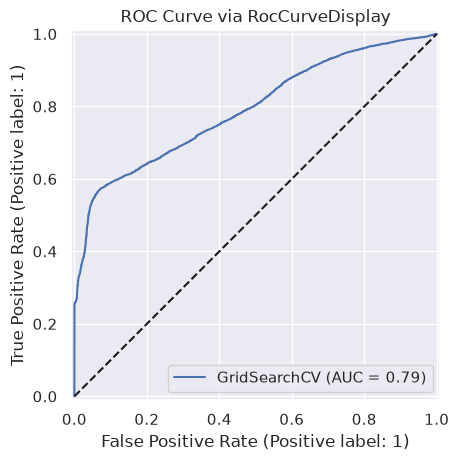

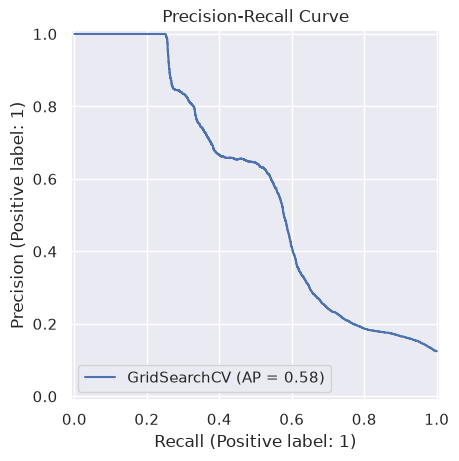

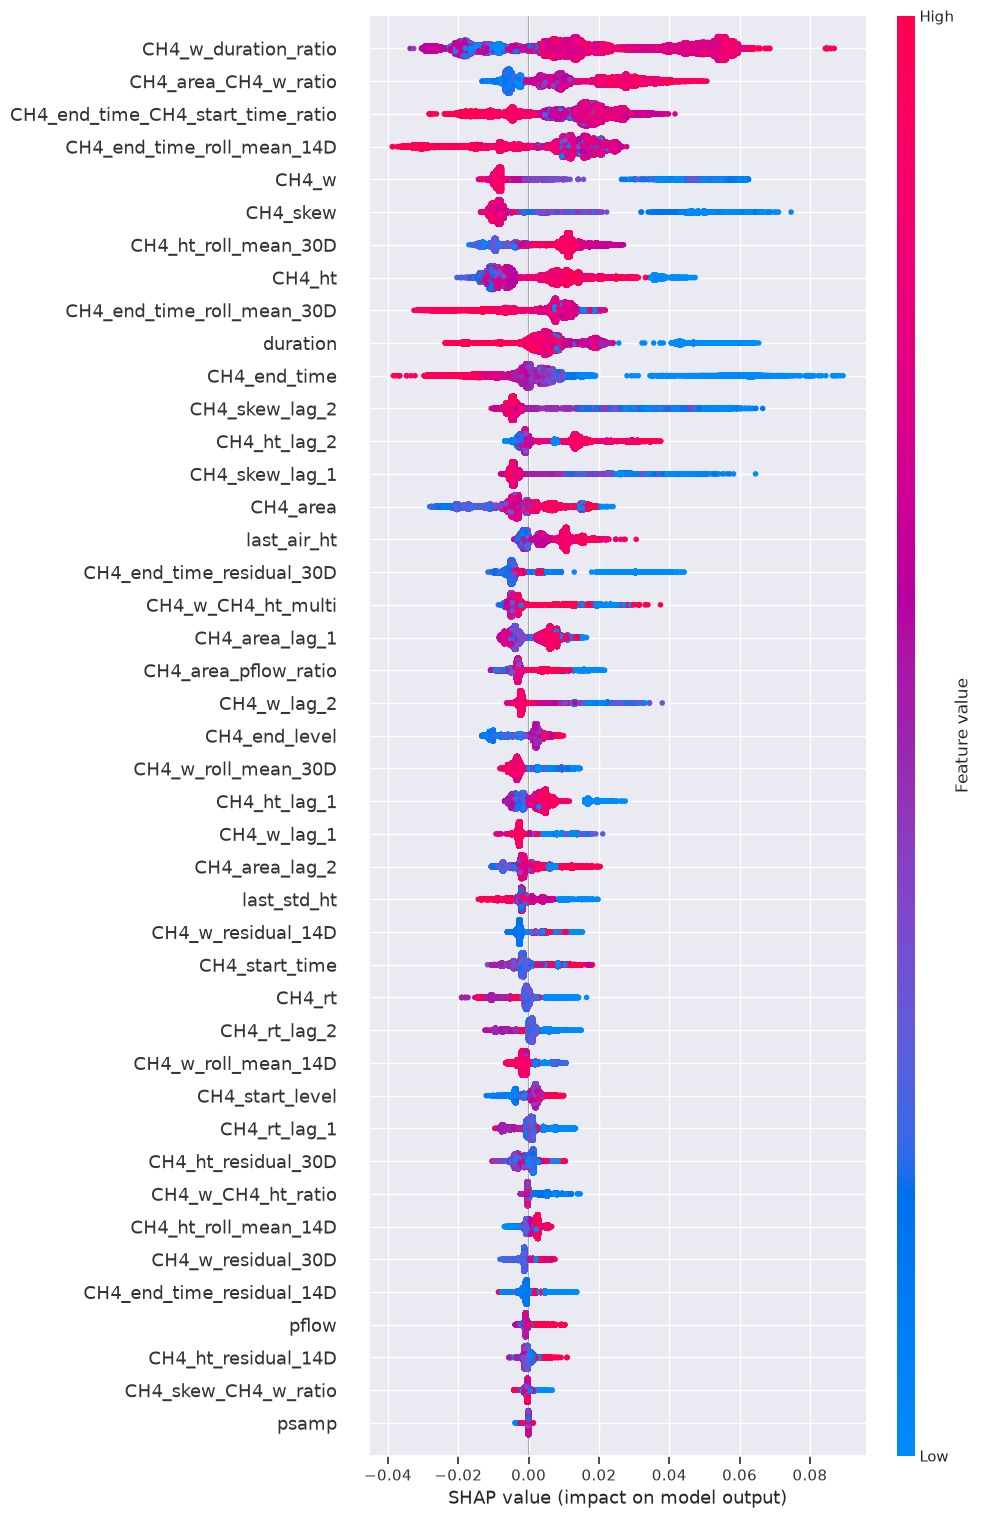

🏃 View run 0715_RF_GridSearch_120_type feature_v1 at: http://127.0.0.1:5000/#/experiments/4/runs/fa67c24af059489caf2fbd65b3b34ce1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4
All Done!


In [19]:
with mlflow.start_run(run_name="0715_RF_GridSearch_120_type feature_v1") as parent_run:
    
    grid = GridSearchCV(estimator=pipe_rnd, param_grid = param_grid, cv=tscv,  scoring='average_precision', n_jobs=4, return_train_score=True)
    grid.fit(X_train_final, y_train_final)

    # print best model score
    cv_results = pd.DataFrame(grid.cv_results_)
    best_index = grid.best_index_
    mean_train = cv_results.loc[best_index, 'mean_train_score']
    mean_test = cv_results.loc[best_index, 'mean_test_score']

    print(f"Best hyparameter set 5-fold mean training AP: {mean_train:.5f}")
    print(f"Best hyparameter set 5- fold mean validation set: {mean_test:.5f}")

        
    X_test_final = tsfe.fit_transform(X_test)
    y_test_final = y_test.copy()
    #=========== plotting
    #======== ROC
    RocCurveDisplay.from_estimator(grid, X_test_final, y_test_final)
    
    plt.title("ROC Curve via RocCurveDisplay")
    plt.plot([0, 1], [0,1], 'k--') 
    plt.savefig("image/ROC_Curve.png")
    mlflow.log_artifact("image/ROC_Curve.png")
    plt.show()    
    plt.close()
    # ======= PRC 
    PrecisionRecallDisplay.from_estimator(grid, X_test_final, y_test_final)

    plt.title("Precision-Recall Curve")
    plt.savefig("image/PRC_Curve.png")
    mlflow.log_artifact("image/PRC_Curve.png")
    plt.show()    
    plt.close()
    #========= SHAP
    best_pipeline = grid.best_estimator_
    final_rf_model = best_pipeline.named_steps['clf']


    explainer = shap.TreeExplainer(final_rf_model)
    shap_values = explainer(X_test_final)

    plt.figure(figsize=(10,15))
    shap.plots.beeswarm(shap_values[:, :, 1], max_display=46, show=False)
    plt.savefig("image/shap_summary.png")
    mlflow.log_artifact("image/shap_summary.png")
    plt.show()    
    plt.close()


print("All Done!")
    


    

    

median 和 fillna(0)差不多

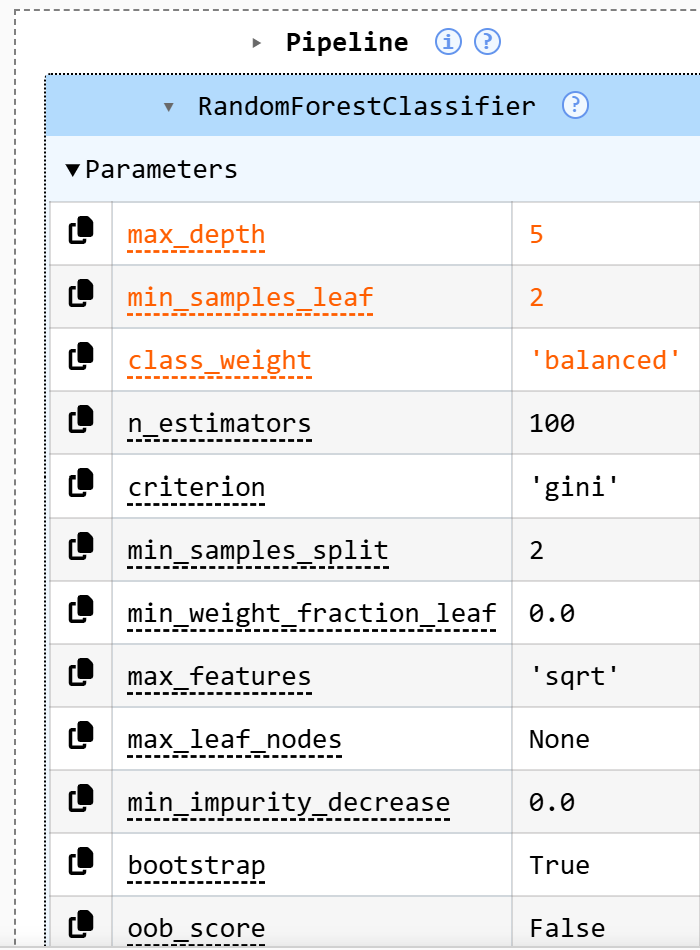

the best one above

cv_results = pd.DataFrame(grid.cv_results_)
best_index = grid.best_index_
mean_train = cv_results.loc[best_index, 'mean_train_score']
mean_test = cv_results.loc[best_index, 'mean_test_score']

print(f"Best hyparameter set 5-fold mean training AP: {mean_train:.5f}")
print(f"Best hyparameter set 5- fold mean validation set: {mean_test:.5f}")

In [47]:
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](44,)","['psamp','pflow','CH4_rt',...,'CH4_end_time_residual_14D', 'CH4_end_time_roll_mean_30D','CH4_end_time_residual_30D']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,44
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The "

In [ ]:
joblib.dump(grid.best_estimator_, 'model/07_rf_best_grid_v2.pkl')

['model/0706_rf_best_grid_v2.pkl']

In [24]:
joblib.dump(grid, 'model/0706_rf_grid_v2.pkl')
print('Done!')

Done!


grid = joblib.load('model/0706_rf_grid_v1.pkl')

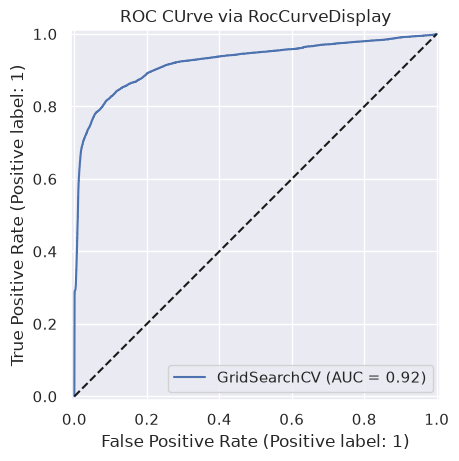

In [26]:
X_test_final = tsfe.fit_transform(X_test)
y_test_final = y_test.copy()
RocCurveDisplay.from_estimator(grid, X_test_final, y_test_final)

plt.title('ROC CUrve via RocCurveDisplay')
plt.plot([0, 1], [0,1], 'k--') 
plt.show()


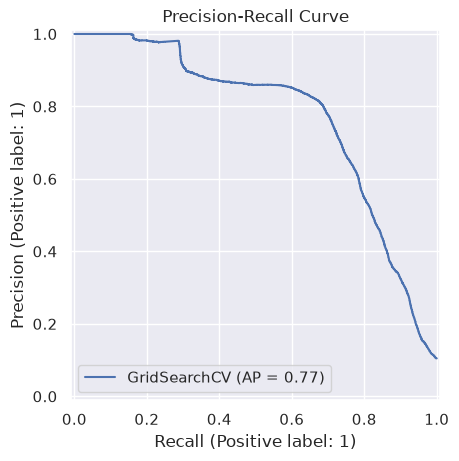

In [ ]:

PrecisionRecallDisplay.from_estimator(grid, X_test_final, y_test_final)

plt.title('Precision-Recall Curve')
plt.show()

In [29]:
X_test_final.columns

Index(['psamp', 'pflow', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew',
       'CH4_start_time', 'CH4_end_time', 'CH4_start_level', 'CH4_end_level',
       'duration', 'is_ht_zero_and_C_Nan', 'is_normal_std',
       'CH4_area_ht_ratio', 'CH4_w_ht_ratio', 'psamp_pflow_ratio',
       'w_duration_ratio', 'CH4_area_diff_1', 'CH4_ht_diff_1',
       'CH4_area_lag_1', 'CH4_rt_lag_1', 'pflow_lag_1', 'CH4_w_lag_1',
       'CH4_skew_lag_1', 'CH4_w_roll_std_14D', 'CH4_skew_roll_std_14D',
       'CH4_rt_roll_mean_14D', 'CH4_rt_residual_14D',
       'CH4_start_time_roll_mean_14D', 'CH4_start_time_residual_14D',
       'CH4_w_roll_mean_14D', 'CH4_w_residual_14D', 'CH4_skew_roll_mean_14D',
       'CH4_skew_residual_14D'],
      dtype='object')

In [ ]:
best_pipeline = grid.best_estimator_
final_rf_model = best_pipeline.named_steps['clf']

X_tsfe_demo = best_pipeline.named_steps['tsfe'].transform(X_test.head(2))
X_tsfe_demo.head()

,tmod,tamb,pflow,psamp,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,duration,is_ht_zero_and_C_Nan,is_bad_std,is_normal_std,is_protential_flagged_air,CH4_area_ht_ratio,CH4_w_ht_ratio,psamp_pflow_ratio,w_duration_ratio,CH4_area_diff_1,CH4_ht_diff_1,CH4_rt_diff_1,CH4_area_lag_1,CH4_rt_lag_1,tmod_lag_1,tamb_lag_1,pflow_lag_1,psamp_lag_1,pamb_lag_1,CH4_w_lag_1,CH4_skew_lag_1,CH4_w_roll_std_14D,CH4_skew_roll_std_14D,CH4_rt_roll_mean_14D,CH4_rt_residual_14D,CH4_start_time_roll_mean_14D,CH4_start_time_residual_14D,CH4_w_roll_mean_14D,CH4_w_residual_14D,CH4_skew_roll_mean_14D,CH4_skew_residual_14D
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2019-07-21 18:43:00,40.0,19.77,803.7,752.75,752.7,102.2,7.37,142932.0,1230362.0,0.9,88.2,140.8,29213.0,29627.0,52.6,0,0,1,0,8.608023,0.000052,0.936606,0.140114,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,102.2,0.0,88.2,0.00,7.37,0.0,0.9
2019-07-21 19:03:00,40.0,19.73,806.8,752.89,752.8,102.2,7.39,139718.0,1206045.0,0.9,88.2,140.6,29194.0,29662.0,52.4,0,0,0,0,8.631994,0.000053,0.933180,0.141031,-24317.0,-3214.0,0.0,1230362.0,102.2,40.0,19.77,803.7,752.75,752.7,7.37,0.9,0.0,0.0,102.2,0.0,88.2,0.0,7.37,0.02,0.9,0.0


In [ ]:
import shap
#============= SHAP
best_pipeline = grid.best_estimator_
final_rf_model = best_pipeline.named_steps['clf']


#X_test_transformed_df = best_pipeline.named_steps['tsfe'].transform(X_test)
    #best_pipeline.named_steps['tsfe'].transform(X_test)
#)


feature_names = X_test_final.columns

X_test_transformed_df = pd.DataFrame(X_test_final, columns =feature_names)
X_test_transformed_df.isna().sum()

tmod                            0
tamb                            0
pflow                           0
psamp                           0
pamb                            0
CH4_rt                          0
CH4_w                           0
CH4_ht                          0
CH4_area                        0
CH4_skew                        0
CH4_start_time                  0
CH4_end_time                    0
CH4_start_level                 0
CH4_end_level                   0
duration                        0
is_ht_zero_and_C_Nan            0
is_bad_std                      0
is_normal_std                   0
is_protential_flagged_air       0
CH4_area_ht_ratio               0
CH4_w_ht_ratio                  0
psamp_pflow_ratio               0
w_duration_ratio                0
CH4_area_diff_1                 0
CH4_ht_diff_1                   0
CH4_rt_diff_1                   0
CH4_area_lag_1                  0
CH4_rt_lag_1                    0
tmod_lag_1                      0
tamb_lag_1    

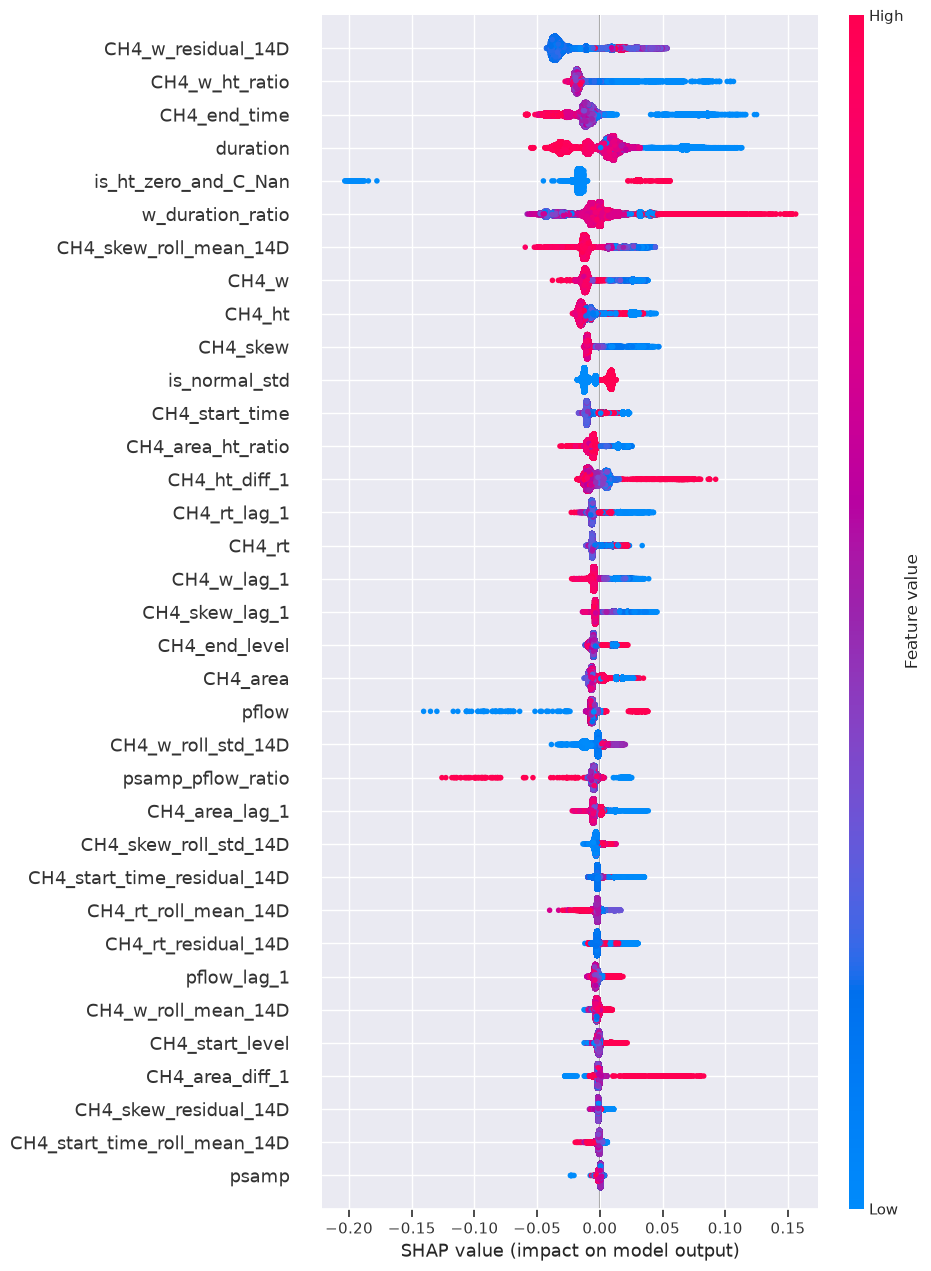

In [30]:
import shap
#============= SHAP
best_pipeline = grid.best_estimator_
final_rf_model = best_pipeline.named_steps['clf']


#X_test_transformed_df = best_pipeline.named_steps['tsfe'].transform(X_test)
    #best_pipeline.named_steps['tsfe'].transform(X_test)
#)

explainer = shap.TreeExplainer(final_rf_model)
shap_values = explainer(X_test_final)

shap.plots.beeswarm(shap_values[:, :, 1], max_display=46) # label1 = 1

------

In [ ]:
# Learning curve
from sklearn.model_selection import LearningCurveDisplay
best_param = grid.best_estimator_

eval_pipeline = pipe_rnd.set_params(**best_param)

LearningCurveDisplay.from_estimator(
    eval_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc',
    train_sizes=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    n_jobs=-1
)

plt.title("Learning Curve (Random Forest)")
plt.show()